# Basis Function Expansion with EXP on a Plummer Sphere

## Introduction

### The Plummer model

The Plummer model ([Plummer 1911](https://doi.org/10.1093/mnras/71.5.460)) is a density profile model first proposed to describe the distribution of stars in globular clusters. However, the model lends well to describe any spherical system with a quasi-constant density core:

$$ \rho(r) = \frac{3M}{4\pi b^3}\left (1+\frac{r^2}{b^2} \right)^{-5/2},$$

where $r$ represents the distance from the center of the distribution, $M$ is the total mass of the system and the parameter $b$ is called the Plummer scale length. The associated potential energy of this system is

$$ \Phi = - \frac{GM}{\sqrt{r^2+b^2}} $$

Because the density and potential distributions are analytically defined, $N$-body simulations of a Plummer model are an ideal benchmark to test how realistic the BFE approximation of these fields are when built on the representation of a system suffering from numerical limitations such as limited particle resolution, two-body relaxation, and non-direct gravity computation methods. Naturally, the following analysis can be repeated with other analytically-defined density profiles.

### Simulation details
The simulation of the Plummer sphere was run with $G=1$, $M=1$, and $b=1$ simulated using $N=10^6$ particles of equal mass. The initial positions of the particles are generated using inverse transform sampling, while the velocities coordinates of the particles are drawn from a Gaussian distribution centered at 0 and with variance equal to the velocity dispersion of the system:

$$ \sigma^2 (r) = \frac{GM}{6\sqrt{r^2+a^2}} $$

The gravitational interaction between particles is computed using the Barnes-Hut treecode  method (as implemented by [pytreegrav](https://pytreegrav.readthedocs.io/en/latest/index.html)) with an opening angle of 0.7 and softening length of 0.1. 

The system is evolved from t=0 to t=100 in time steps of 0.01. 

In [1]:
# Make imports
import corner
import gala.dynamics as gd
import gala.potential as gp
from gala.units import DimensionlessUnitSystem
import k3d
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import pynbody
import pyEXP
from scipy.ndimage import gaussian_filter1d
from scipy.stats import entropy
import yaml

In [2]:
# Read the simulation outputs
output_dir = "/mnt/home/asante/ceph/PlummerNbody/N6/"

outputs = os.listdir(output_dir)
outputs = [o for o in outputs if ".npz" in o]
# Order files by snapshot
t_outputs = sorted([float(out.replace("Plummer_outs_t","").replace(".npz","")) for out in outputs])
outputs = [f"Plummer_outs_t{int(t):03}.npz" for t in t_outputs]


# Load position, velocity, and masses of particles at first and last snapshot
data_initial = np.load(f"{output_dir}{outputs[0]}", allow_pickle=True)
data_final = np.load(f"{output_dir}{outputs[-1]}", allow_pickle=True)

# Create pynbody object and center particle distribution
sim_initial = pynbody.new(dark=1000000)
sim_initial["pos"] = data_initial["x"]
sim_initial["mass"] = data_initial["m"]
pynbody.analysis.center(sim_initial, with_velocity=False)

sim_final = pynbody.new(dark=1000000)
sim_final["pos"] = data_final["x"]
sim_final["mass"] = data_final["m"]
pynbody.analysis.center(sim_final, with_velocity=False)

<Transformation null, translate>

Text(0.5, 1.0, '(y,z)')

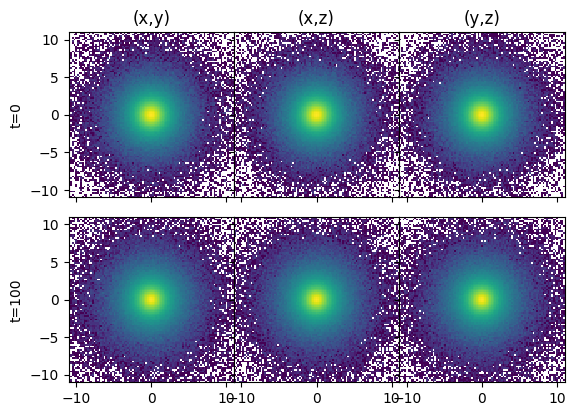

In [3]:
# Visualize the system 
lims = 11

# Visualize cluster final configuration
fig,axs = plt.subplots(2,3, sharex=True, sharey=True, gridspec_kw={"wspace":0,"hspace":0})
for i,sim in enumerate([sim_initial,sim_final]):
    _ = axs[i,0].hist2d(sim["pos"][:,0], sim["pos"][:,1], norm="log", bins=np.linspace(-lims,lims,100))
    _ = axs[i,1].hist2d(sim["pos"][:,0], sim["pos"][:,2], norm="log", bins=np.linspace(-lims,lims,100))
    _ = axs[i,2].hist2d(sim["pos"][:,1], sim["pos"][:,2], norm="log", bins=np.linspace(-lims,lims,100))

for ax in axs.flatten():
    ax.set_aspect(1)

axs[0,0].set_ylabel("t=0")
axs[1,0].set_ylabel("t=100")

axs[0,0].set_title("(x,y)")
axs[0,1].set_title("(x,z)")
axs[0,2].set_title("(y,z)")


/tmp/ipykernel_3804246/2676678573.py:56: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  axs[0].set_xlim([0,10])


Text(0, 0.5, '$\\rho(r)_{Plummer}-\\rho(r)$')

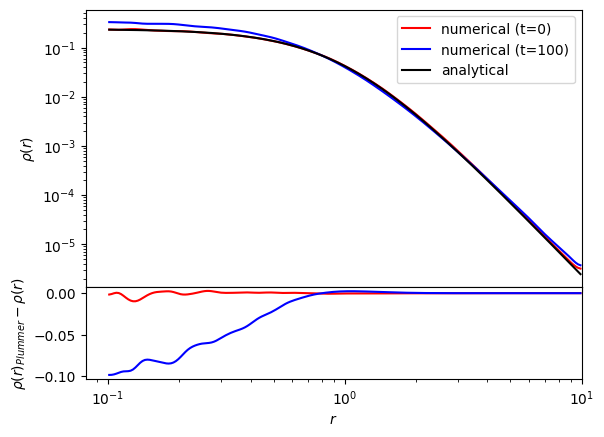

In [4]:
# Plot density profile

def return_density(r,weights=1.,rangevals=[-2, 6],bins=500,log=True, smooth=False):    
    if log:
        r = np.log10(r)
        rangevals = np.log10(rangevals)
        # Radial bins edges
        rbins = np.linspace(rangevals[0], rangevals[1], bins)
        # Calculate the volume of each shell defined by two radial bins
        V = 4/3*np.pi*(np.power(10,rbins[1:])**3 - np.power(10,rbins[:-1])**3)
        
    else:
        rbins = np.linspace(rangevals[0], rangevals[1], bins)
        # Calculate the volume of each shell defined by two radial bins
        V = 4/3*np.pi*(rbins[1:]**3 - rbins[:-1]**3)
        
    # Calculate the total mass in each shell
    M, _ = np.histogram(r, bins=rbins, weights=weights)
    # Evaluate the density
    density = M / V 
    # Calculate the centre of the radial bins
    rcentre = 0.5 * (rbins[:-1] + rbins[1:])
    
    if smooth:
        # Smooth density values
        density = gaussian_filter1d(density, 3.)
        
    if log:
        rcentre = np.power(10,rcentre)

    return rcentre,density

def plum_rho(r,M,a,G):
    rho = (3.*M/4./np.pi/a**3)/(1.+(r/a)**2)**2.5
    return rho

density_params_df = {"bins": 200,
                     "rangevals": [0.1,10]}

rbins, dvals = return_density(r=np.sqrt(np.sum(sim_initial["pos"]**2,axis=1)), 
                              weights=sim_initial["mass"], **density_params_df, 
                              smooth=True)
rbinsf, dvalsf = return_density(r=np.sqrt(np.sum(sim_final["pos"]**2,axis=1)), 
                                weights=sim_final["mass"], **density_params_df, 
                                smooth=True)

# Plot inferred density vs analytical density
plum_dens = plum_rho(r=rbins, M=1., a=1., G=1.)
fig,axs = plt.subplots(2,1, gridspec_kw={"hspace":0, "height_ratios":[3,1]}, sharex=True)
axs[0].plot(rbins, dvals, label="numerical (t=0)", c="r")
axs[0].plot(rbins, dvalsf, label="numerical (t=100)", c="b")
axs[0].plot(rbins, plum_dens, label="analytical", c="k")
axs[0].set_yscale("log")
axs[0].set_xscale("log")
axs[0].set_ylabel("$\\rho(r)$")
axs[0].set_xlim([0,10])
axs[0].legend()

axs[1].plot(rbins, plum_dens-dvals, c="r")
axs[1].plot(rbins, plum_dens-dvalsf, c="b")
axs[1].set_xlabel("$r$")
axs[1].set_ylabel("$\\rho(r)_{Plummer}-\\rho(r)$")

The difference in the density profile of the system between the initial ($t=0$) and final ($t=100$) state are due to two-body relaxation which causes particles to loose energy causing the system to "collapse" and reach a denser state in order to maintain equilibrium.

## Basis function expansion with EXP 

### Build the basis

In [5]:
# Define functions for basis construction
def return_density(r,weights=1.,rangevals=[-2, 6],bins=500,log=True, smooth=False):    
    if log:
        r = np.log10(r)
        rangevals = np.log10(rangevals)
        # Radial bins edges
        rbins = np.linspace(rangevals[0], rangevals[1], bins)
        # Calculate the volume of each shell defined by two radial bins
        V = 4/3*np.pi*(np.power(10,rbins[1:])**3 - np.power(10,rbins[:-1])**3)
        
    else:
        rbins = np.linspace(rangevals[0], rangevals[1], bins)
        # Calculate the volume of each shell defined by two radial bins
        V = 4/3*np.pi*(rbins[1:]**3 - rbins[:-1]**3)
        
    # Calculate the total mass in each shell
    M, _ = np.histogram(r, bins=rbins, weights=weights)
    # Evaluate the density
    density = M / V 
    # Calculate the centre of the radial bins
    rcentre = 0.5 * (rbins[:-1] + rbins[1:])
    
    if smooth:
        # Smooth density values
        density = gaussian_filter1d(density, 3.)
        
    if log:
        rcentre = np.power(10,rcentre)

    return rcentre,density

def makemodel_empirical(rvals,dvals,pfile='',plabel = '',verbose=True):
    """make an EXP-compatible spherical basis function table

    inputs
    -------------
    rvals       : (array of floats) radius values to evaluate the density function
    pfile       : (string) the name of the output file. If '', will not print file
    plabel      : (string) comment string, printed to the top of the file
    verbose     : (boolean)

    outputs
    -------------
    R           : (array of floats) the radius values
    D           : (array of floats) the density
    M           : (array of floats) the mass enclosed
    P           : (array of floats) the potential

    """
    M = 1.
    R = np.nanmax(rvals)

    # make the mass and potential arrays
    mvals = np.zeros(dvals.size)
    pvals = np.zeros(dvals.size)
    pwvals = np.zeros(dvals.size)

    # initialise the mass enclosed an potential energy
    mvals[0] = 1.e-15
    pwvals[0] = 0.

    # evaluate mass enclosed and potential energy by recursion
    for indx in range(1,dvals.size):
        mvals[indx] = mvals[indx-1] +\
          2.0*np.pi*(rvals[indx-1]*rvals[indx-1]*dvals[indx-1] +\
                 rvals[indx]*rvals[indx]*dvals[indx])*(rvals[indx] - rvals[indx-1]);
        pwvals[indx] = pwvals[indx-1] + \
          2.0*np.pi*(rvals[indx-1]*dvals[indx-1] + rvals[indx]*dvals[indx])*(rvals[indx] - rvals[indx-1]);

    # evaluate potential (see theory document)
    pvals = -mvals/(rvals+1.e-10) - (pwvals[dvals.size-1] - pwvals)

    # get the maximum mass and maximum radius
    M0 = mvals[dvals.size-1]
    R0 = rvals[dvals.size-1]

    # compute scaling factors
    Beta = (M/M0) * (R0/R);
    Gamma = np.sqrt((M0*R0)/(M*R)) * (R0/R);
    if verbose:
        print("! Scaling:  R=",R,"  M=",M)

    rfac = np.power(Beta,-0.25) * np.power(Gamma,-0.5);
    dfac = np.power(Beta,1.5) * Gamma;
    mfac = np.power(Beta,0.75) * np.power(Gamma,-0.5);
    pfac = Beta;

    if verbose:
        print(rfac,dfac,mfac,pfac)

    # save file if desired
    if pfile != '':
        f = open(pfile,'w')
        print('! ',plabel,file=f)
        print('! R    D    M    P',file=f)

        print(rvals.size,file=f)

        for indx in range(0,rvals.size):
            print('{0} {1} {2} {3}'.format( rfac*rvals[indx],\
              dfac*dvals[indx],\
              mfac*mvals[indx],\
              pfac*pvals[indx]),file=f)

        f.close()

    return rvals*rfac,dfac*dvals,mfac*mvals,pfac*pvals


In [102]:
# Construct the basis in four steps:
def build_basis(sim_data, lmax=6, nmax=20, runtag="run0", use_cached=False):
    
    # 1 - Calculate density profile of the system
    rbins, dvals = return_density(r=np.sqrt(np.sum(sim_data["pos"]**2,axis=1)), 
                                weights=sim_data["mass"], **density_params_df, 
                                smooth=True)

    # 2 - Create an EXP-compatible spherical basis function table 
    model_file = f"{output_dir}basis_empirical_PlummerTest_{runtag}.txt" 
    cache_file = model_file.replace(f"_{runtag}.txt",f".cache.{runtag}")

    ### Check if model or table have already been computed
    if not use_cached:
        if os.path.exists(model_file):
            os.remove(model_file)
        if os.path.exists(cache_file):
            os.remove(cache_file)

    rbins, dvals, mass, potential = makemodel_empirical(rvals=rbins,
                                                        dvals=dvals,
                                                        pfile=model_file) 

    # 3 - Specify the basis configuration (e.g. basis type and order of expansion)  

    config = {"id" : "sphereSL",
              "parameters": {"numr": 1000,
                            "rmin": 0.01,
                            "rmax": 10,
                            "Lmax": lmax,
                            "nmax": nmax,
                            "rmapping": 0.1,
                            "modelname": model_file,
                            "cachename": cache_file,
                            "pcavar": True, # enable to calculate the coefficients covariance matrix 
                            "subsamp": 1000,
                            },
               "runtag": "run0",
               "outdir": output_dir
            }

    ### Save yaml file for constructing gala potential
    yaml_file = f"{output_dir}basis_yaml_PlummerTest.yml"

    with open(yaml_file, "w") as f:
        yaml.dump(config, f, default_flow_style=False)
        
        
    # 4 - Construct the basis
    with open(yaml_file, "r") as f:
        yaml_config = f.read()
    basis = pyEXP.basis.Basis.factory(yaml_config)
    
    return basis, yaml_file

basis, basis_yaml = build_basis(sim_data=sim_final)

! Scaling:  R= 9.884959046625584   M= 1.0
1.0 1.0126077394566122 1.0126077394566124 1.0126077394566124


---- SLGridSph::ReadH5Cache: error reading </mnt/home/asante/ceph/PlummerNbody/N6/basis_empirical_PlummerTest.cache.run0>
---- SLGridSph::ReadH5Cache: HDF5 error is <Unable to open file /mnt/home/asante/ceph/PlummerNbody/N6/basis_empirical_PlummerTest.cache.run0 (File accessibility) Unable to open file>


---- SLGridSph::WriteH5Cache: wrote </mnt/home/asante/ceph/PlummerNbody/N6/basis_empirical_PlummerTest.cache.run0>
---- Spherical::orthoTest: worst=0.00326932


### Calculate the coefficients and covariance matrix

In [7]:
# Calculate the coefficients of the basis at the different snapshots
def get_coefs(basis, time_step_cadence, t_start=0, runtag="run0"):
    
    os.chdir(output_dir)
    
    step_size = 100/len(t_outputs)
    idx_snaps_interval = int(time_step_cadence / step_size)

    # Select snapshots to conisder 
    idx_snapshots = [i for i in range(0, len(t_outputs), idx_snaps_interval)
                     if t_outputs[i]>=t_start]

    # Calculate coefficients
    coefs_container = None

    for idx in idx_snapshots:
        
        data_file = np.load(f"{output_dir}{outputs[idx]}")
        
        # Center
        sim = pynbody.new(dark=1000000)
        sim["pos"] = data_file["x"]
        sim["mass"] = data_file["m"]

        pynbody.analysis.center(sim, with_velocity=False)

        coefs = basis.createFromArray(sim["mass"],
                                      sim["pos"], 
                                      time=t_outputs[idx])

        basis.writeCoefCovariance("sphereSL", runtag, t_outputs[idx])
        
        if coefs_container is None:
            coefs_container = pyEXP.coefs.Coefs.makecoefs(coefs)
            coefs_container.add(coefs)
        else:
            coefs_container.add(coefs)
            
    # Save the coefficients
    coefs_file = f"{output_dir}coefs_PlummerTest_{runtag}.h5"
    if os.path.exists(coefs_file):
        os.remove(coefs_file)
        coefs_container.WriteH5Coefs(coefs_file) 
    else:
        coefs_container.WriteH5Coefs(coefs_file)
        
    return coefs_container, coefs_file

coefs, coefs_file = get_coefs(basis, time_step_cadence=10, t_start=0)

In [8]:
# Read-in the covariance matrix of the coefficients
runtag="run0"
covar = pyEXP.basis.CovarianceReader(f'{output_dir}/coefcovar.sphereSL.{runtag}.h5')

### Visualize the approximated density and potential fields

In [9]:
# Define visualization functions
def surface_projection(basis,
                       coefs,
                       field: str, # dens, dens m=0, dens m>0, potl, potl m-0, ...
                       time: float,
                       extent: list, # e.g. [[xmin, ymin, 0.],[xmax, ymax, 0.]]
                       grid: list, # [bins_x, bins_y, 0.]
                       ax
                       ):
        
        # Initialise surface field generator
        times = coefs.Times()
    
        generator = pyEXP.field.FieldGenerator(times, 
                                               extent[0], 
                                               extent[1], 
                                               grid)
        
        surfaces = generator.slices(basis, coefs)

        surface = surfaces[time][field]

        non_zero_entries = [i for i in range(3) if grid[i]!=0]

        x = np.linspace(extent[0][non_zero_entries[0]],
                        extent[1][non_zero_entries[0]],
                        grid[non_zero_entries[0]])
        
        y = np.linspace(extent[0][non_zero_entries[1]],
                        extent[1][non_zero_entries[1]],
                        grid[non_zero_entries[1]])
        
        xv, yv = np.meshgrid(x, y)
        
   
        cont1 = ax.contour(xv, yv, surface, colors='k')
        cont1.clabel(fontsize=9, inline=True)
        cont2 = ax.contourf(xv, yv, surface)

        return 

def volume_render(basis,
                  coefs,
                  time: float, 
                  field: str,
                  grid_lim: int = 100,
                  n_points: int = 100):

    # Calculate 3D distribution of fields
    times = coefs.Times()
    pmin  = [-grid_lim, -grid_lim, -grid_lim]
    pmax  = [grid_lim, grid_lim, grid_lim]
    grid  = [n_points, n_points, n_points]

    generator = pyEXP.field.FieldGenerator(times, pmin, pmax, grid)
    volumes = generator.volumes(basis, coefs)

    volume = np.abs(volumes[time][field])

    # Initialise plot
    plot = k3d.plot()

    value_range = [np.percentile(volume, 5), np.percentile(volume, 95)]
    size = [-grid_lim, grid_lim, -grid_lim, grid_lim, -grid_lim, grid_lim]

    volume = k3d.volume(volume.astype(np.float32), 
                        alpha_coef=5,
                        color_range=value_range,  
                        color_map=k3d.matplotlib_color_maps.Viridis, 
                        compression_level=7)
    
    volume.transform.bounds = [-size[0], size[0], -size[1], size[1], -size[2], size[2]]

    plot += volume
    
    return plot

def plot_coefs_evolution(coefs, 
                         l, 
                         m,
                         ax):
    
    coefs_values = coefs.getAllCoefs()
    times = coefs.Times()
    
    spherical_index = (l * (l + 1)) // 2 + m
    n_radial_terms = coefs_values.shape[1]

    cmap = mpl.colormaps["inferno"]
    norm = mpl.colors.Normalize(vmin=0, vmax=n_radial_terms)
    sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)

    for n_radial in range(n_radial_terms):
        ax.plot(times, 
                coefs_values[spherical_index, n_radial, :],
                c=cmap(norm(n_radial)))
        
    ax.set_yscale("log")
    ax.set_ylabel("Coefficients amplitude")
    ax.set_xlabel("Time")

    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label("Radial order")

    ax.set_title(f"l={l}, m={m}")
    return ax


Text(0.5, 1.0, '(y,z)')

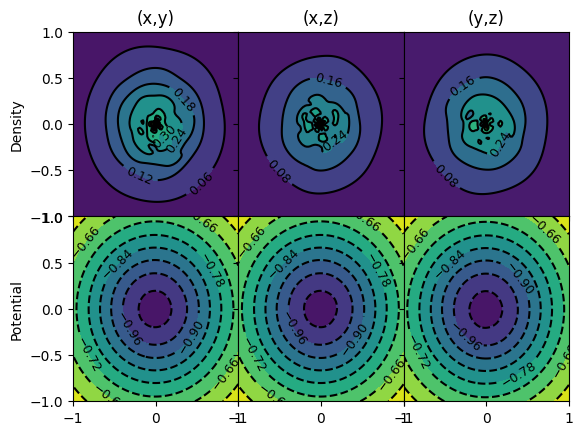

In [10]:
# 2D projections of the density and potential fields
fig,axs = plt.subplots(2,3,sharex=True, sharey=True, 
                       gridspec_kw={"wspace":0, "hspace":0})

for i,field in enumerate(["dens", "potl"]):
    surface_projection(basis=basis,
                        coefs=coefs,
                        field=field, 
                        time=coefs.Times()[-1],
                        extent=[[-1,-1,0],[1,1,0]],
                        grid=[100,100,0],
                        ax=axs[i,0])

    surface_projection(basis=basis,
                        coefs=coefs,
                        field=field, 
                        time=coefs.Times()[-1],
                        extent=[[-1,0,-1],[1,0,1]],
                        grid=[100,0,100],
                        ax=axs[i,1])

    surface_projection(basis=basis,
                        coefs=coefs,
                        field=field, 
                        time=coefs.Times()[-1],
                        extent=[[0,-1,-1],[0,1,1]],
                        grid=[0,100,100],
                        ax=axs[i,2])

axs[0,0].set_ylabel("Density")
axs[1,0].set_ylabel("Potential")

axs[0,0].set_title("(x,y)")
axs[0,1].set_title("(x,z)")
axs[0,2].set_title("(y,z)")



In [11]:
# 3D representation of the density field
plot = volume_render(basis=basis,
                     coefs=coefs,
                     time=coefs.Times()[-1],
                     field="dens",
                     grid_lim=1,
                     n_points=100)
plot

Plot(antialias=3, axes=['x', 'y', 'z'], axes_helper=1.0, axes_helper_colors=[16711680, 65280, 255], background…

In [12]:
# 3D representation of the potential field
plot2 = volume_render(basis=basis,
                      coefs=coefs,
                      time=coefs.Times()[-1],
                      field="potl",
                      grid_lim=1,
                      n_points=100)
plot2

Plot(antialias=3, axes=['x', 'y', 'z'], axes_helper=1.0, axes_helper_colors=[16711680, 65280, 255], background…

/mnt/home/asante/streams_in_dreams/expgala/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/mnt/home/asante/streams_in_dreams/expgala/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


<Axes: title={'center': 'l=2, m=0'}, xlabel='Time', ylabel='Coefficients amplitude'>

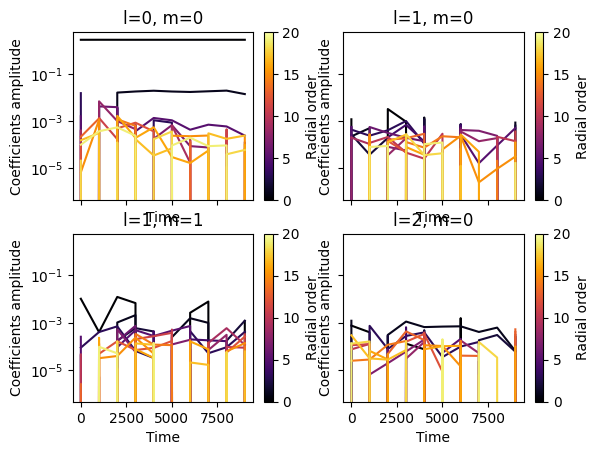

In [15]:
# Plot coefficient amplitudes for the first four modes
fig,axs = plt.subplots(2,2, sharex=True, sharey=True)
plot_coefs_evolution(coefs, l=0, m=0, ax=axs[0,0])
plot_coefs_evolution(coefs, l=1, m=0, ax=axs[0,1])
plot_coefs_evolution(coefs, l=1, m=1, ax=axs[1,0])
plot_coefs_evolution(coefs, l=2, m=0, ax=axs[1,1])

## Evaluation tools

When performing a BFE approximation, two questions that arise naturally are:
- at what order should the expansion be truncated?
- how different is the approximated field to the "truth"?

The former can be addressed by considering the contribution of each basis to the field reconstruction as measured by their "signal-to-noise" ratio.

The latter can be measured either through a direct comparison with the "true" field (if the information is available) or indirectly looking into quantities which are directly affected by the state of the field, e.g. particle orbits in a potential field. 


### Signal-to-Noise Ratio

'# Make plot at t=0\nSNR_mesh = []\n\nfor l in range(lmax+1):\n    for m in range(l+1):\n        SNR_ml = get_SNR(covar=covar, time=t, l=l, m=m, decorrelate=True)\n        SNR_mesh.append(SNR_ml)\n\nSNR_mesh = np.vstack(SNR_mesh)\n\nfig,ax = plt.subplots()\nplot = ax.pcolormesh(SNR_mesh, \n                     norm="log", \n                     cmap="RdYlBu",\n                     vmin=vmin, vmax=vmax)\ncbar = fig.colorbar(plot,ax=ax)\ncbar.set_label("SNR")\n\nax.set_xlabel("Radial nth mode")\nax.set_ylabel("Angular (l,m) mode")\nax.set_aspect(1)\nax.set_title(f"Time: {t}")'

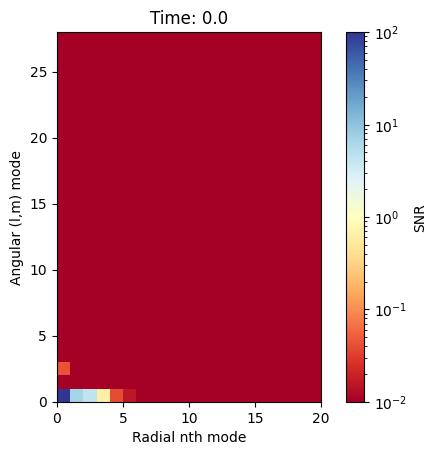

In [91]:
def get_SNR(covar, time, l, m, decorrelate=False):
    """
    Returns the signal-to-noise (SNR, i.e. amplitude to variance) ratio for the coefficients 
    of the basis functions for all the radial orders associated to the given m and l 
    orders at a given time. 

    Args:
        covar (CovarianceReader): pyEXP object containing information on the coefficients
                                  values and covariance matrix at the given time
        time (float): time at which the coefficients are evaluated
        l (int): degree of the angular function in the expansion
        m (int): modes of l

    Returns:
        ndarray: array of the SNR for each radial mode at the specified angular mode
    """
    SNR = None
    nmax=20
    
    # Get the values and covariance of the coefficients for the basis at time t
    # output is a list where each element refers to a given spherical orders
    coefs_var_subsamples = covar.getCoefCovariance(time)
    
    n_subsamples = len(coefs_var_subsamples)
    
    # Define the index of the coefficients and covariance basis in the outputs
    spherical_index = (l * (l + 1)) // 2 + m
                    
    # Read coefficients from each subsample
    sumCof = np.zeros((nmax), dtype=np.complex128)
    sumVar = np.zeros((nmax, nmax), dtype=np.complex128)
    for subsample in coefs_var_subsamples:
        sumCof += subsample[spherical_index][0]
        sumVar += subsample[spherical_index][1]
    # Subtract cross-samples covariance
    sumVar -= np.outer(sumCof, sumCof.conj())
    
    if decorrelate:
        # Make eigenvalue analysis on covariance matrix
        val, vec = np.linalg.eigh(sumVar)
        # Project coefficients into decorrelated basis
        b = np.dot(vec.T, sumCof)
        
        SNR = np.abs(b)**2 * n_subsamples / np.abs(val)
    
    else:
    
        SNR = np.abs(sumCof)**2 *n_subsamples / np.abs(np.diag(sumVar))
    
    return SNR


lmax=6
nmax=20

t = coefs.Times()[0]
vmin = 0.01
vmax = 100

# Make plot at t=0
SNR_mesh = []

for l in range(lmax+1):
    for m in range(l+1):
        SNR_ml = get_SNR(covar=covar, time=t, l=l, m=m)
        SNR_mesh.append(SNR_ml)

SNR_mesh = np.vstack(SNR_mesh)

fig,ax = plt.subplots()
plot = ax.pcolormesh(SNR_mesh, 
                     norm="log", 
                     cmap="RdYlBu",
                     vmin=vmin, vmax=vmax)
cbar = fig.colorbar(plot,ax=ax)
cbar.set_label("SNR")

ax.set_xlabel("Radial nth mode")
ax.set_ylabel("Angular (l,m) mode")
ax.set_aspect(1)
ax.set_title(f"Time: {t}")


"""# Make plot at t=0
SNR_mesh = []

for l in range(lmax+1):
    for m in range(l+1):
        SNR_ml = get_SNR(covar=covar, time=t, l=l, m=m, decorrelate=True)
        SNR_mesh.append(SNR_ml)

SNR_mesh = np.vstack(SNR_mesh)

fig,ax = plt.subplots()
plot = ax.pcolormesh(SNR_mesh, 
                     norm="log", 
                     cmap="RdYlBu",
                     vmin=vmin, vmax=vmax)
cbar = fig.colorbar(plot,ax=ax)
cbar.set_label("SNR")

ax.set_xlabel("Radial nth mode")
ax.set_ylabel("Angular (l,m) mode")
ax.set_aspect(1)
ax.set_title(f"Time: {t}")"""

### Orbit metrics

Set-up Gala potential objects for the analytical Plummer potential and the EXP reconstruction

In [12]:
# Define Gala potential object from EXP approximation
pot = gp.EXPPotential(units=DimensionlessUnitSystem(),
                      config_file=basis_yaml,
                      coef_file=coefs_file)

pot_a = gp.PlummerPotential(m=1,
                            b=1,
                            units=DimensionlessUnitSystem())

---- SLGridSph::ReadH5Cache: successfully read basis cache </mnt/home/asante/ceph/PlummerNbody/N6/basis_empirical_PlummerTest.cache.run0>
---- Spherical::orthoTest: worst=0.00326932


In [13]:
# Sample test particles from simulation
rng = np.random.default_rng(16)
N=int(1e6)

idx_particles = rng.choice(N, size=100, replace=False)

# Save positions and velocities of particles at the different snapshots
r_sim,v_sim,E_sim = [],[],[]

for output in outputs[::10]:
    data = np.load(f"{output_dir}{output}", allow_pickle=True)
    r_sim.append(data["x"][idx_particles])
    v_sim.append(data["v"][idx_particles])
    E_sim.append(data['pot'][idx_particles] + 0.5*np.sum(data["v"][idx_particles]**2,axis=1))

r_sim = np.stack(r_sim, axis=1) # (particle_index, time_index, coordinate)
v_sim = np.stack(v_sim, axis=1)
E_sim = np.stack(E_sim,axis=1) # (particle_index, time_index)

"""rng = np.random.default_rng(16)
N = 1000

x0 = rng.normal(loc=0, scale=1, size=(3,N))
r = np.sqrt(np.sum(x0**2,axis=0))
# Define escape velocity
v_esc = np.sqrt(2/np.sqrt(r**2+1))
# Initialize velocity vectors at random
v0 = np.abs(rng.normal(loc=0, scale=1, size=(3,N)))
# Get unit vectors
v0 /= np.sqrt(np.sum(v0**2,axis=0))
# Ensure velocities are less than the escape velocity
f_vesc = rng.uniform(high=0.9, size=N)
v0 *= f_vesc"""

'rng = np.random.default_rng(16)\nN = 1000\n\nx0 = rng.normal(loc=0, scale=1, size=(3,N))\nr = np.sqrt(np.sum(x0**2,axis=0))\n# Define escape velocity\nv_esc = np.sqrt(2/np.sqrt(r**2+1))\n# Initialize velocity vectors at random\nv0 = np.abs(rng.normal(loc=0, scale=1, size=(3,N)))\n# Get unit vectors\nv0 /= np.sqrt(np.sum(v0**2,axis=0))\n# Ensure velocities are less than the escape velocity\nf_vesc = rng.uniform(high=0.9, size=N)\nv0 *= f_vesc'

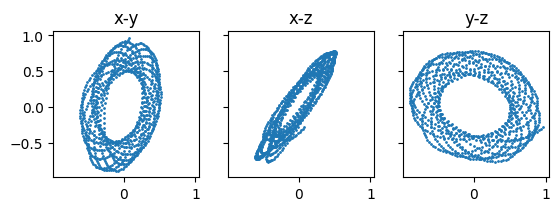

In [14]:
# Plot an example of an orbit from the N-body simulation
idx = 30
fig,axs = plt.subplots(1,3, sharex=True, sharey=True)
axs[0].scatter(r_sim[idx,:,0], r_sim[idx,:,1], s=1)
axs[1].scatter(r_sim[idx,:,0], r_sim[idx,:,2], s=1)
axs[2].scatter(r_sim[idx,:,1], r_sim[idx,:,2], s=1)
axs[0].set_title('x-y')
axs[1].set_title('x-z')
axs[2].set_title('y-z')
for ax in axs.flatten():
    ax.set_aspect(1)

In [15]:
# Integrate orbits of particles in the analytic and EXP potentials

import gala.integrate as gi

def save_attrs_to_df(orbit):
    
    E = orbit.energy()
    peri = orbit.pericenter()
    apo = orbit.apocenter()
    ecc = orbit.eccentricity()
    L = orbit.angular_momentum()
    
    df = {"E": E,
        "peri": peri,
        "apo": apo,
        "e": ecc,
        "Lx": L[0,:,:],
        "Ly": L[1,:,:],
        "Lz": L[2,:,:],
        "x": orbit.x.value,
        "y": orbit.y.value,
        "z": orbit.z.value,
        "vx": orbit.v_x.value,
        "vy": orbit.v_y.value,
        "v_z": orbit.v_z.value
        }
    
    return df

orbits_ics = gd.PhaseSpacePosition(pos=r_sim[:,0,:].T,
                                   vel=v_sim[:,0,:].T)
orbits_a = pot_a.integrate_orbit(orbits_ics, t1=0, t2=100, n_steps=500, Integrator=gi.DOPRI853Integrator)
orbits_exp = pot.integrate_orbit(orbits_ics, t1=0, t2=100, n_steps=500, Integrator=gi.DOPRI853Integrator, Integrator_kwargs={"atol":1e-4})

df_a = save_attrs_to_df(orbits_a)
df_exp = save_attrs_to_df(orbits_exp)

/mnt/home/asante/streams_in_dreams/expgala/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/mnt/home/asante/streams_in_dreams/expgala/lib/python3.11/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [83]:
from scipy.stats import wasserstein_distance_nd
import matplotlib.lines as mlines

def compare_distributions(data1, data2, labels=None, title=None):
    """
    Overlays two multidimensional distributions on a corner plot.
    
    Parameters:
    -----------
    data1 : np.ndarray
        First distribution (N_samples, N_dim).
    data2 : np.ndarray
        Second distribution (N_samples, N_dim).
    labels : list of str, optional
        Labels for the dimensions (e.g., ['x', 'y', 'z', 'vx']).
    title : str, optional
        Title for the figure.
    """
    # 1. Define colors and range
    # Get the combined range to ensure axes are identical for both
    # We compute min/max across both datasets for each dimension
    mins = np.min([data1.min(axis=0), data2.min(axis=0)], axis=0)
    maxs = np.max([data1.max(axis=0), data2.max(axis=0)], axis=0)
    # Add a small buffer (5%)
    ranges = [[mn - 0.05*(mx-mn), mx + 0.05*(mx-mn)] for mn, mx in zip(mins, maxs)]

    # 2. Plot the first distribution (Blue)
    # We save the figure object to pass it to the second call
    figure = corner.corner(data1, 
                           labels=labels,
                           range=ranges,
                           color='tab:blue', 
                           smooth=1.0,           # Smooths contours slightly
                           plot_datapoints=False, # Don't plot scatter points if N is large
                           plot_density=False,    # Don't fill contours (optional style)
                           fill_contours=True,
                           hist_kwargs={'density': True, 'linewidth': 2},
                           alpha=0.4)            # Transparency for fill

    # 3. Overplot the second distribution (Orange) on the SAME figure
    corner.corner(data2, 
                  fig=figure,                # Pass the existing figure
                  range=ranges,              # MUST use same ranges
                  color='tab:orange',
                  smooth=1.0,
                  plot_datapoints=False,
                  plot_density=False,
                  fill_contours=True,
                  hist_kwargs={'density': True, 'linewidth': 2},
                  alpha=0.4)

    # 4. Add Legend (Manual, since corner doesn't support easy auto-legends)
    blue_line = mlines.Line2D([], [], color='tab:blue', label='Dist 1')
    orange_line = mlines.Line2D([], [], color='tab:orange', label='Dist 2')
    plt.legend(handles=[blue_line, orange_line], 
               bbox_to_anchor=(0., 1.0, 1., .0), 
               loc="upper right",
               fontsize=12)
    
    if title:
        plt.suptitle(title, fontsize=16)

    return figure


def get_data_from_df(df):

    L_i = np.sqrt(np.sum(np.vstack([df["Lx"][0], df["Ly"][0], df["Lz"][0]])**2,axis=0))
    L_f = np.sqrt(np.sum(np.vstack([df["Lx"][-1], df["Ly"][-1], df["Lz"][-1]])**2,axis=0))

    df1 = pd.DataFrame({"Ei": df["E"][0],
                        "Ef": df["E"][-1],
                        "peri": df["peri"],
                        "apo": df["apo"],
                        "e": df["e"],
                        "Li": L_i,
                        "Lf": L_f
    })

    df1.dropna(inplace=True)

    return df1.values

def make_comparison(df_a, df_exp):

    sim_orbits = get_data_from_df(df_a)
    bfe_orbits = get_data_from_df(df_exp)

    diff = wasserstein_distance_nd(sim_orbits, bfe_orbits)
    fig = compare_distributions(data1=sim_orbits,
                                data2=bfe_orbits,
                                labels=["E initial", "E final", "Pericenter", "Apocenter", "Eccentricity", "L initial", "L final"],
                                title=f"Diff {diff:.2f}")

    return

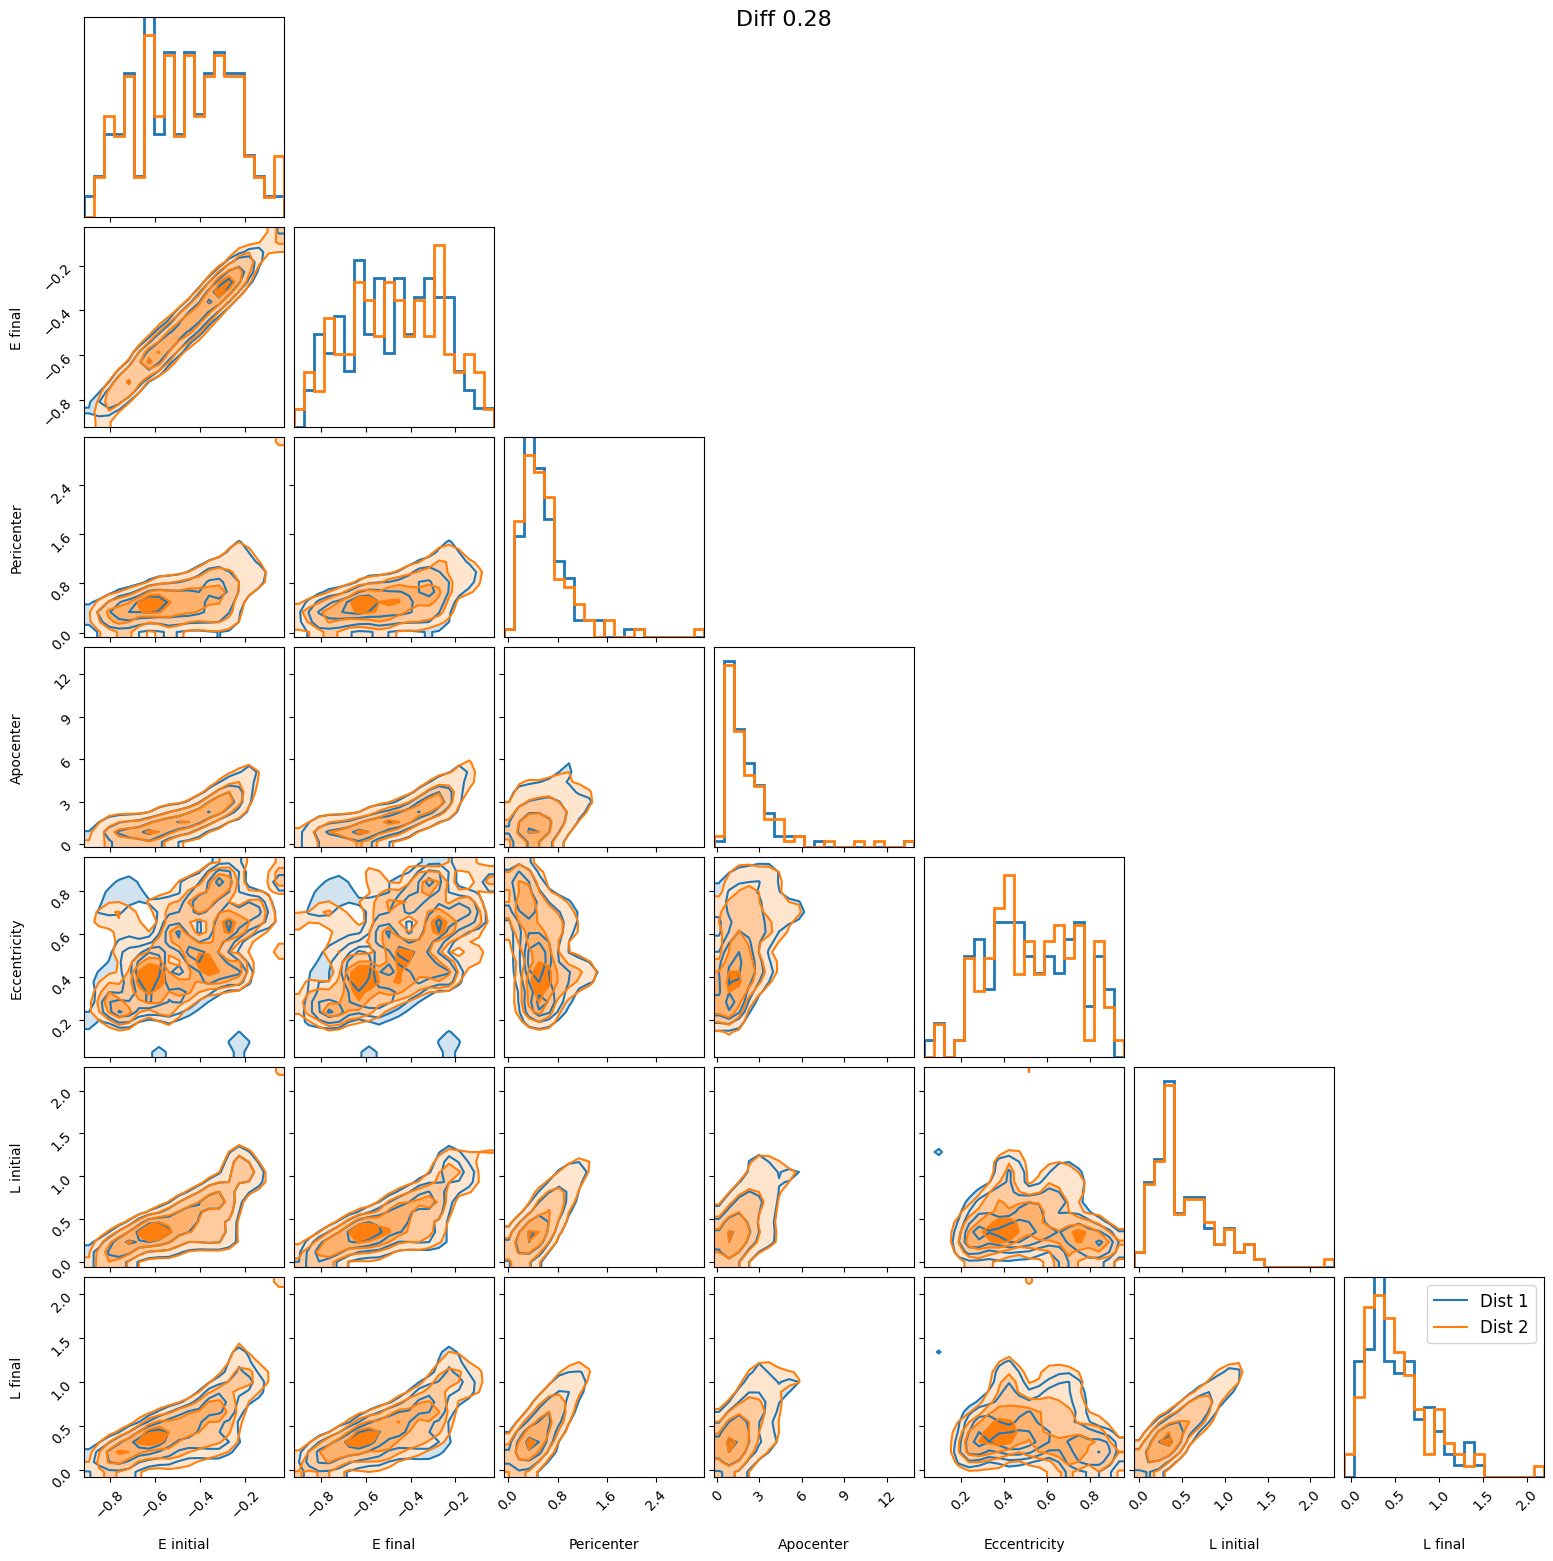

In [84]:
make_comparison(df_a, df_exp)

NameError: name 'similaritymeasures' is not defined

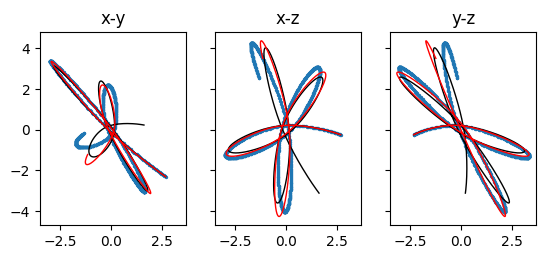

In [16]:
idx = 16


fig,axs = plt.subplots(1,3, sharex=True, sharey=True)
axs[0].set_title('x-y')
axs[1].set_title('x-z')
axs[2].set_title('y-z')
for ax in axs.flatten():
    ax.set_aspect(1)


axs[0].scatter(r_sim[idx,:,0], r_sim[idx,:,1], s=2, label="N-body")
axs[1].scatter(r_sim[idx,:,0], r_sim[idx,:,2], s=2, label="N-body")
axs[2].scatter(r_sim[idx,:,1], r_sim[idx,:,2], s=2, label="N-body")

axs[0].plot(df_a["x"][:,idx], df_a["y"][:,idx], label="Plummer", c="k", lw=1)
axs[1].plot(df_a["x"][:,idx], df_a["z"][:,idx], label="Plummer", c="k", lw=1)
axs[2].plot(df_a["y"][:,idx], df_a["z"][:,idx], label="Plummer", c="k", lw=1)

axs[0].plot(df_exp["x"][:,idx], df_exp["y"][:,idx], label="EXP", c="r", lw=1)
axs[1].plot(df_exp["x"][:,idx], df_exp["z"][:,idx], label="EXP", c="r", lw=1)
axs[2].plot(df_exp["y"][:,idx], df_exp["z"][:,idx], label="EXP", c="r", lw=1)

handles, labels = axs[0].get_legend_handles_labels()

# Calculate Fréchet distance between curves
path_nbody = r_sim[idx, :, :] 
path_plummer = np.column_stack((df_a["x"][:, idx], df_a["y"][:, idx], df_a["z"][:, idx]))
path_exp = np.column_stack((df_exp["x"][:, idx], df_exp["y"][:, idx], df_exp["z"][:, idx]))

fd_nbody = similaritymeasures.frechet_dist(path_plummer, path_nbody)
fd_exp = similaritymeasures.frechet_dist(path_plummer, path_exp)

stats_text = (
    f"Fréchet Distances (vs Plummer):\n"
    f"N-body: {fd_nbody:.4f}\n"
    f"EXP:    {fd_exp:.4f}"
)

fig.text(
    0.5, 0.1, 
    stats_text, 
    ha='center', 
    fontsize=11, 
)
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(0.91, 0.5))


Text(0.5, 0, 'Time')

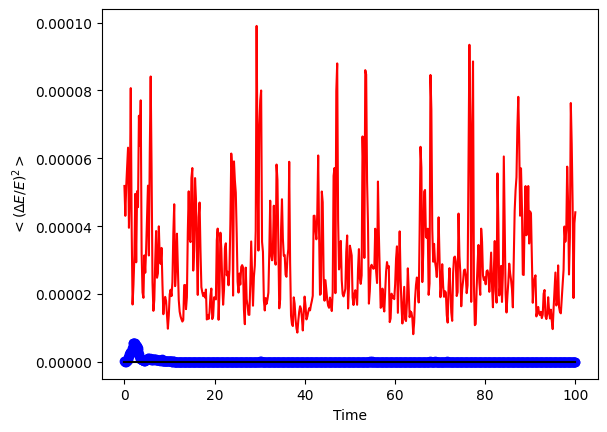

In [197]:
# Difference in energy over time
dE_E_a = np.mean( (np.diff(df_a["E"],axis=0) / df_a["E"][:-1])**2 , axis=1)
dE_E_exp = np.mean( (np.diff(df_exp["E"],axis=0) / df_exp["E"][:-1])**2 , axis=1)
dE_E_Nbody = np.mean((np.diff(E_sim,axis=1) / E_sim[:,:-1])**2, axis=0 )

fig,ax = plt.subplots()
ax.scatter(np.linspace(0,100,999), dE_E_Nbody, c="b", label="N-body")
ax.plot(np.linspace(0,100,499),dE_E_a, c="k", label="Plummer")
ax.plot(np.linspace(0,100,499),dE_E_exp, c="r", label="EXP")
ax.set_ylabel("$<(\Delta E/E)^{2}>$")
ax.set_xlabel("Time")


KeyError: 'Ei'

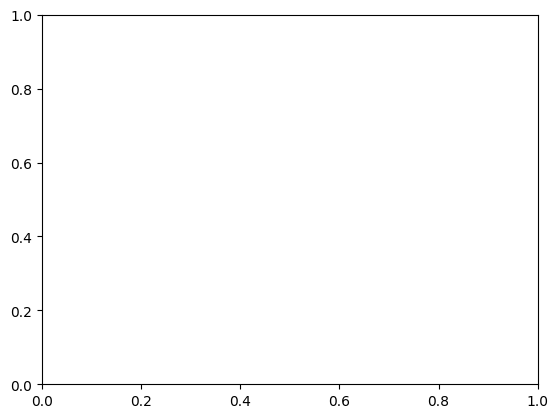

In [17]:
# Visualize the difference in the orbits reconstructed in the Plummer and EXP potentials
fig,ax = plt.subplots()

ax.scatter(df_a["Ei"], df_a["Ef"]-df_a["Ei"], c="k", s=0.1)
ax.scatter(df_exp["Ei"], df_exp["Ef"]-df_exp["Ei"], c="r", s=0.1)
ax.set_xlabel("Initial Energy")
ax.set_ylabel("Final - Initial Energy")
ax.set_ylim([-0.1,0.1])


## 

features = ["Ei", "Ef", "apo", "peri", "e"]
colors = ["k", "r"]

KL = entropy(df_exp[features].values,
             df_a[features].values,
             nan_policy="omit")

common_entries = df_a.dropna(inplace=False).index.intersection(df_exp.dropna(inplace=False).index)
df1 = df_a.loc[common_entries]
df2 = df_exp.loc[common_entries]


for i,df in enumerate([df1, df2]):
    if i ==0:
        fig = corner.corner(df[features].values,
                                        color=colors[i],
                                        labels=features,
                                        bins=20,
                                        plot_contours=True,
                                        plot_datapoints=False,
                                        fill_contours=True,
                                        hist_kwargs={"density": True},
                                        alpha=0.5,
                                        #range=RANGE,
                                        label_kwargs={'fontsize': 18},
                                        )
        
    else:
        corner.corner(df[features].values,
                                        color=colors[i],
                                        labels=features,
                                        bins=20,
                                        plot_contours=True,
                                        plot_datapoints=False,
                                        fill_contours=True,
                                        hist_kwargs={"density": True},
                                        alpha=0.5,
                                        #range=RANGE,
                                        label_kwargs={'fontsize': 18},
                                        fig=fig
                                        )
        
        
fig.suptitle(f"l=6 | n =20")


def mse(x1, x2):
    return np.mean(np.sqrt((x1-x2)**2),axis=0)

for f in features:
    MSE = mse(df2[f].values, 
              df1[f].values)
    KL = entropy(df2[f].values,
                 df1[f].values,
                 nan_policy="omit")
    print(f"MSE ({f}): {MSE:.3f}")
    print(f"KL ({f}): {KL:.4f}")
    print("=====")
    

## Changing the order of the Expansion

As noticed from the study of the signal-to-noise ratio of the coefficients of the basis, the term that is contributing most of the "signal" to the expansion is the monopole. Hence, the expansion can be repeated considering just that term and a better approximation of the system can be expected as the terms contributing noise to the expansion are effectively truncated. 

### Lmax=0 Nmax=5

In [85]:
new_basis, new_basis_yaml = build_basis(sim_data=sim_final, lmax=0, nmax=5, runtag="run1")
new_coefs, new_coefs_file = get_coefs(basis=new_basis, time_step_cadence=10, t_start=0, runtag="run1")

! Scaling:  R= 9.884959046625584   M= 1.0
1.0 1.0126077394566122 1.0126077394566124 1.0126077394566124
---- SLGridSph::WriteH5Cache: wrote </mnt/home/asante/ceph/PlummerNbody/N6/basis_empirical_PlummerTest.cache.run1>
---- Spherical::orthoTest: worst=0.000473642


---- SLGridSph::ReadH5Cache: error reading </mnt/home/asante/ceph/PlummerNbody/N6/basis_empirical_PlummerTest.cache.run1>
---- SLGridSph::ReadH5Cache: HDF5 error is <Unable to open file /mnt/home/asante/ceph/PlummerNbody/N6/basis_empirical_PlummerTest.cache.run1 (File accessibility) Unable to open file>


Text(0.5, 1.0, '(y,z)')

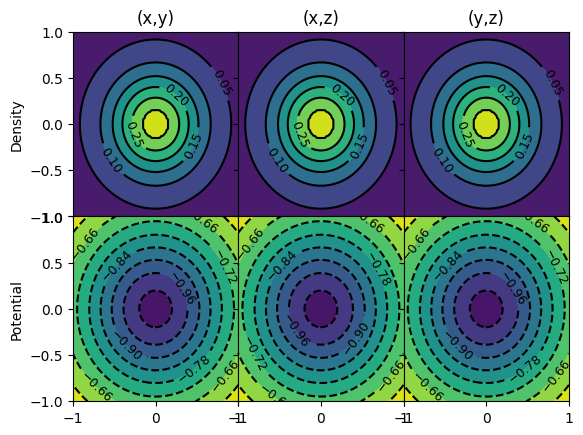

In [86]:
# 2D projections of the density and potential fields
fig,axs = plt.subplots(2,3,sharex=True, sharey=True, 
                       gridspec_kw={"wspace":0, "hspace":0})

for i,field in enumerate(["dens", "potl"]):
    surface_projection(basis=new_basis,
                        coefs=new_coefs,
                        field=field, 
                        time=new_coefs.Times()[-1],
                        extent=[[-1,-1,0],[1,1,0]],
                        grid=[100,100,0],
                        ax=axs[i,0])

    surface_projection(basis=new_basis,
                        coefs=new_coefs,
                        field=field, 
                        time=new_coefs.Times()[-1],
                        extent=[[-1,0,-1],[1,0,1]],
                        grid=[100,0,100],
                        ax=axs[i,1])

    surface_projection(basis=new_basis,
                        coefs=new_coefs,
                        field=field, 
                        time=new_coefs.Times()[-1],
                        extent=[[0,-1,-1],[0,1,1]],
                        grid=[0,100,100],
                        ax=axs[i,2])

axs[0,0].set_ylabel("Density")
axs[1,0].set_ylabel("Potential")

axs[0,0].set_title("(x,y)")
axs[0,1].set_title("(x,z)")
axs[0,2].set_title("(y,z)")



---- SLGridSph::ReadH5Cache: successfully read basis cache </mnt/home/asante/ceph/PlummerNbody/N6/basis_empirical_PlummerTest.cache.run1>
---- Spherical::orthoTest: worst=0.000473642


/mnt/home/asante/streams_in_dreams/expgala/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/mnt/home/asante/streams_in_dreams/expgala/lib/python3.11/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Text(0.5, 0, 'Time')

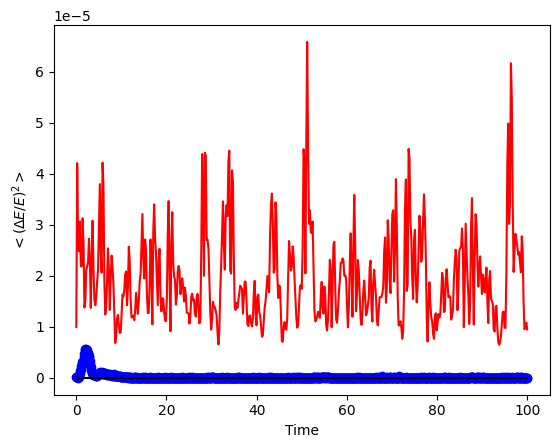

In [87]:
# Repeat orbits analysis with these new basis
# 
# Define Gala potential object from EXP approximation
new_pot = gp.EXPPotential(units=DimensionlessUnitSystem(),
                          config_file=new_basis_yaml,
                          coef_file=new_coefs_file)


new_orbits_exp = new_pot.integrate_orbit(orbits_ics, t1=0, t2=100, n_steps=500)
new_df_exp = save_attrs_to_df(new_orbits_exp)


# Visualize the difference in the orbits reconstructed in the Plummer and EXP potentials

dE_E_a = np.mean( (np.diff(df_a["E"],axis=0) / df_a["E"][:-1])**2 , axis=1)
dE_E_exp = np.mean( (np.diff(new_df_exp["E"],axis=0) / new_df_exp["E"][:-1])**2 , axis=1)
dE_E_Nbody = np.mean((np.diff(E_sim,axis=1) / E_sim[:,:-1])**2, axis=0 )

fig,ax = plt.subplots()
ax.scatter(np.linspace(0,100,999), dE_E_Nbody, c="b", label="N-body")
ax.plot(np.linspace(0,100,499),dE_E_a, c="k", label="Plummer")
ax.plot(np.linspace(0,100,499),dE_E_exp, c="r", label="EXP")
ax.set_ylabel("$<(\Delta E/E)^{2}>$")
ax.set_xlabel("Time")

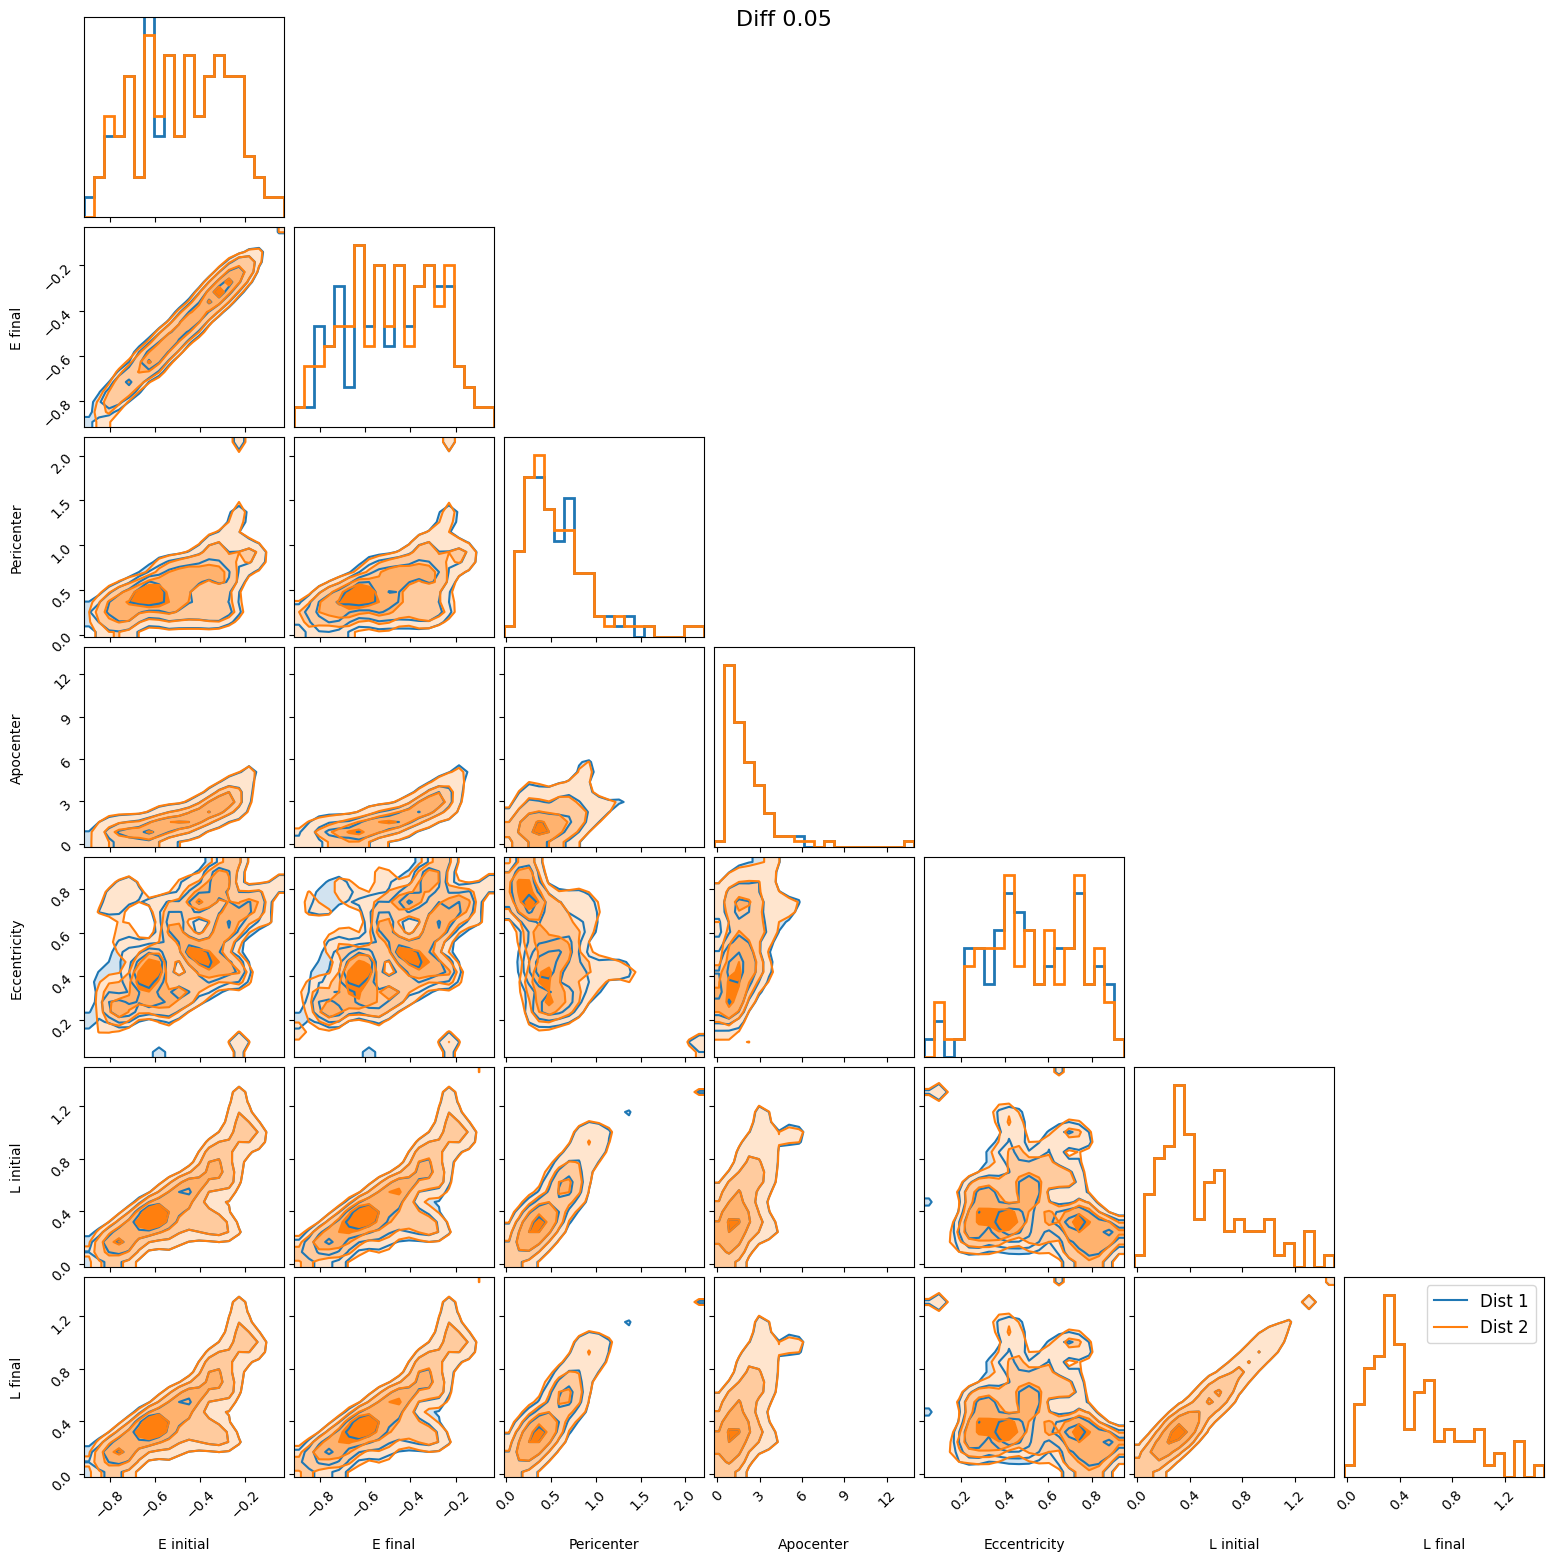

In [88]:
make_comparison(df_a, new_df_exp)

## Relating Signal-to-Noise analysis to Orbit fidelity





In [94]:
def suppress_coefficients(coefs_file,
                          mask,
                          update=False):
        
    # Read original coefficients
    coefs = pyEXP.coefs.Coefs.factory(coefs_file)
    coefs_values = coefs.getAllCoefs()
    
    # Mask coefficient at each snapshot
    for i,time in enumerate(coefs.Times()):
        new_coefs = coefs_values[:,:,i]
        new_coefs[mask] = np.complex128(0)
        coefs.setMatrix(time, coefs_values[:,:,i])
        
    # Write new coefficient file
    new_coefs_file = coefs_file.replace(".h5","_masked.h5")
    
    if os.path.exists(new_coefs_file):
        os.remove(new_coefs_file)
    coefs.WriteH5Coefs(new_coefs_file) 
    

    return new_coefs_file

In [105]:
masked_coefs_file = suppress_coefficients(coefs_file, SNR_mesh<10)

In [106]:
masked_pot = gp.EXPPotential(units=DimensionlessUnitSystem(),
                          config_file=basis_yaml,
                          coef_file=masked_coefs_file)


masked_orbits_exp = masked_pot.integrate_orbit(orbits_ics, t1=0, t2=100, n_steps=500)
masked_df_exp = save_attrs_to_df(new_orbits_exp)

---- SLGridSph::ReadH5Cache: successfully read basis cache </mnt/home/asante/ceph/PlummerNbody/N6/basis_empirical_PlummerTest.cache.run0>
---- Spherical::orthoTest: worst=0.00326932


/mnt/home/asante/streams_in_dreams/expgala/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/mnt/home/asante/streams_in_dreams/expgala/lib/python3.11/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


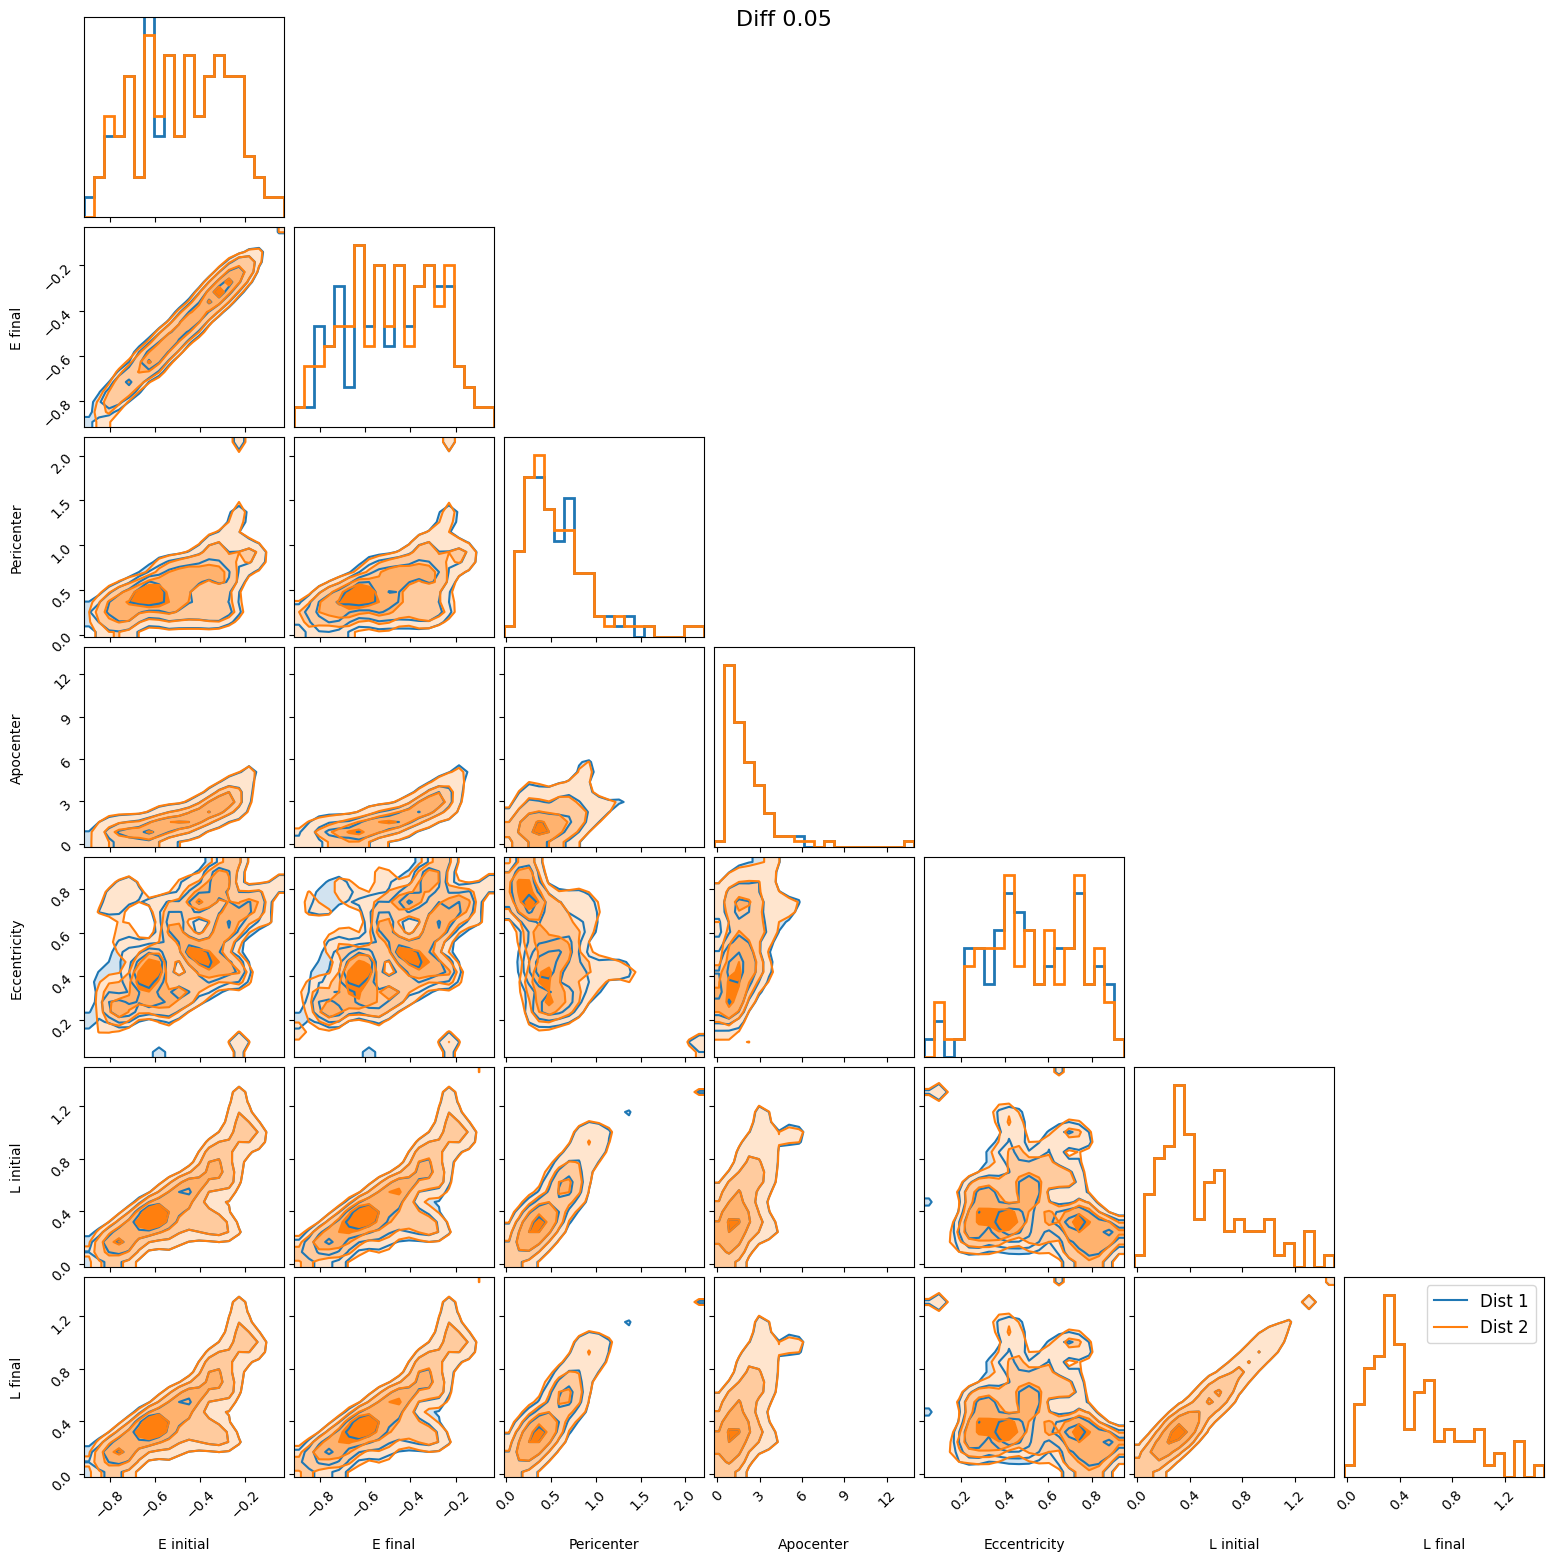

In [107]:
make_comparison(df_a, masked_df_exp)